<a href="https://colab.research.google.com/github/akshita52/Data_Engg_Assignment/blob/main/Data_Engg_and_AI_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM 1: MULTIVARIATE LINEAR REGRESSION**


In [44]:
# Step 1: Import libraries
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [45]:
# Step 2: Create dataset
data = {
    'Experience':[2,5,1,8,4,10,3,6,7,2],
    'Training':[40,60,20,80,50,90,30,70,75,25],
    'Working':[38,42,35,45,40,48,37,44,46,36],
    'Projects':[3,6,2,8,5,9,4,7,7,3],
    'Score':[62,78,55,88,72,92,65,82,85,60]
}
df = pd.DataFrame(data)
print("DATASET:\n", df)

DATASET:
    Experience  Training  Working  Projects  Score
0           2        40       38         3     62
1           5        60       42         6     78
2           1        20       35         2     55
3           8        80       45         8     88
4           4        50       40         5     72
5          10        90       48         9     92
6           3        30       37         4     65
7           6        70       44         7     82
8           7        75       46         7     85
9           2        25       36         3     60


In [46]:
# Step 3: Split features and target
X = df[['Experience','Training','Working','Projects']]
y = df['Score']

In [47]:
# Step 4: Train model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [48]:
# Step 5: Coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print("Model Coefficients:\n")
print(coeff_df)
print("\nIntercept:", model.intercept_)

Model Coefficients:

      Feature  Coefficient
0  Experience    -0.963801
1    Training     0.038009
2     Working     0.819005
3    Projects     4.701357

Intercept: 17.425339366515693


In [49]:
# Step 6: Predictions
df["Predicted"] = model.predict(X)

In [50]:
# Step 7: R² Score
r2 = model.score(X, y)
print("\nR^2 Score:", r2)


R^2 Score: 0.9972374438067544


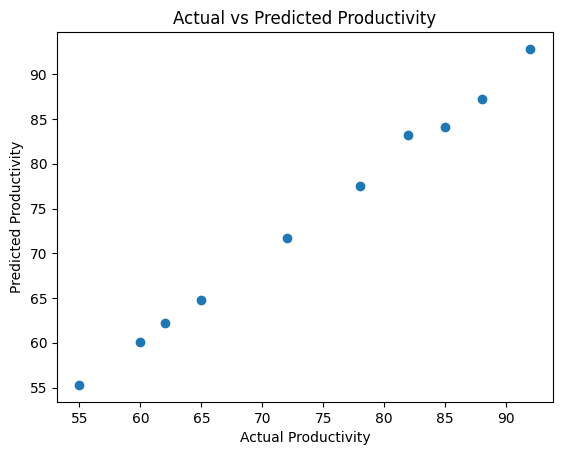

In [51]:
# Step 8: Visualization (Actual vs Predicted)
plt.scatter(y, df["Predicted"])
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted Productivity")
plt.show()

# **PROBLEM 2: LOGISTIC REGRESSION (FRAUD DETECTION)**

In [52]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

In [53]:
# Step 2: Create dataset (aligned with first code)
data = {
    "Amount": [1200,50,5000,200,1500,75,3200,40,2100,60],
    "TimeSinceLastTxn": [2,24,1,48,3,72,2,96,5,120],
    "LocationChange": [1,0,1,0,1,0,1,0,1,0],
    "AvgTxnAmount": [500,200,450,300,700,150,400,100,600,120],
    "ForeignTxn": [1,0,1,0,1,0,1,0,1,0],
    "HighRiskCountry": [1,0,1,0,0,0,1,0,1,0],
    "CardPresent": [0,1,0,1,0,1,0,1,0,1],
    "IsFraud": [1,0,1,0,1,0,1,0,1,0]
}
df = pd.DataFrame(data)
print("DATASET:\n",df)

DATASET:
    Amount  TimeSinceLastTxn  LocationChange  AvgTxnAmount  ForeignTxn  \
0    1200                 2               1           500           1   
1      50                24               0           200           0   
2    5000                 1               1           450           1   
3     200                48               0           300           0   
4    1500                 3               1           700           1   
5      75                72               0           150           0   
6    3200                 2               1           400           1   
7      40                96               0           100           0   
8    2100                 5               1           600           1   
9      60               120               0           120           0   

   HighRiskCountry  CardPresent  IsFraud  
0                1            0        1  
1                0            1        0  
2                1            0        1  
3             

In [54]:
# Step 3: Features and target
X = df.drop("IsFraud", axis=1)
y = df["IsFraud"]

In [55]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [56]:
# Step 5: Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [57]:
# Step 6: Coefficients (same style as first code)
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
print("Model Coefficients:\n")
print(coeff_df)
print("\nIntercept:", model.intercept_)

Model Coefficients:

            Feature  Coefficient
0            Amount     0.026585
1  TimeSinceLastTxn    -0.049740
2    LocationChange     0.000050
3      AvgTxnAmount    -0.041688
4        ForeignTxn     0.000050
5   HighRiskCountry     0.000020
6       CardPresent    -0.000538

Intercept: [-0.00103098]


In [58]:
# Step 7: Predict probabilities
y_probs = model.predict_proba(X_test)[:, 1]

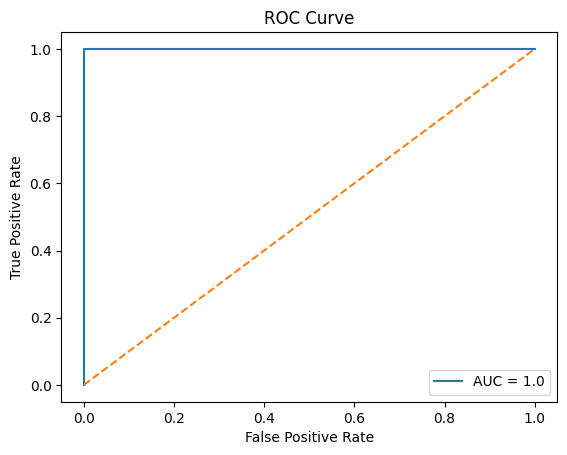

In [59]:
# Step 8: ROC Curve + AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)
plt.plot(fpr, tpr, label="AUC = " + str(auc_score))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [60]:
# Step9: Threshold tuning (example threshold = 0.3)
threshold = 0.3
y_pred_custom = (y_probs >= threshold).astype(int)
print("\nConfusion Matrix (Threshold = 0.3):")
print(confusion_matrix(y_test, y_pred_custom))


Confusion Matrix (Threshold = 0.3):
[[2 0]
 [0 1]]


In [61]:
# Step 10: L2 Regularization model
model_l2 = LogisticRegression(penalty='l2', solver='liblinear')
model_l2.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [62]:
# Step 11: L1 Regularization model
model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
model_l1.fit(X_train, y_train)
print("\nL2 Coefficients:")
print(model_l2.coef_)
print("\nL1 Coefficients:")
print(model_l1.coef_)


L2 Coefficients:
[[ 2.57051811e-02 -4.44782945e-02  4.71858826e-05 -4.17676478e-02
   4.71858826e-05  2.52869441e-05 -4.79428215e-04]]

L1 Coefficients:
[[ 0.01531159 -0.03670529  0.         -0.02246625  0.          0.
   0.        ]]


# **PROBLEM 3: CUSTOMER SEGMENTATION (K-MEANS)**

In [63]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [64]:
# Step 2: Dataset
df = pd.DataFrame({
    "CustomerID":[1,2,3,4,5,6,7,8,9,10],
    "Age":[22,25,47,52,23,45,33,35,60,28],
    "AnnualIncome":[15000,18000,60000,65000,20000,70000,40000,42000,80000,30000],
    "SpendingScore":[39,81,6,20,77,15,50,55,10,70],
    "VisitsPerMonth":[4,6,2,3,5,2,4,5,1,6],
    "AvgOrderValue":[200,500,150,200,450,180,300,320,100,400]
})
print("DATASET:\n",df)

DATASET:
    CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0           1   22         15000             39               4            200
1           2   25         18000             81               6            500
2           3   47         60000              6               2            150
3           4   52         65000             20               3            200
4           5   23         20000             77               5            450
5           6   45         70000             15               2            180
6           7   33         40000             50               4            300
7           8   35         42000             55               5            320
8           9   60         80000             10               1            100
9          10   28         30000             70               6            400


In [65]:
# Step 3: Basic check
print("Missing values:\n", df.isnull().sum())
print("\nSummary stats:\n", df.describe())

Missing values:
 CustomerID        0
Age               0
AnnualIncome      0
SpendingScore     0
VisitsPerMonth    0
AvgOrderValue     0
dtype: int64

Summary stats:
        CustomerID        Age  AnnualIncome  SpendingScore  VisitsPerMonth  \
count    10.00000  10.000000     10.000000      10.000000        10.00000   
mean      5.50000  37.000000  44000.000000      42.300000         3.80000   
std       3.02765  13.266499  23518.314376      28.488009         1.75119   
min       1.00000  22.000000  15000.000000       6.000000         1.00000   
25%       3.25000  25.750000  22500.000000      16.250000         2.25000   
50%       5.50000  34.000000  41000.000000      44.500000         4.00000   
75%       7.75000  46.500000  63750.000000      66.250000         5.00000   
max      10.00000  60.000000  80000.000000      81.000000         6.00000   

       AvgOrderValue  
count      10.000000  
mean      280.000000  
std       135.728487  
min       100.000000  
25%       185.000000  
5

In [66]:
# Step 4: Remove ID column
X = df.drop(columns=["CustomerID"])

In [67]:
# Step 5: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

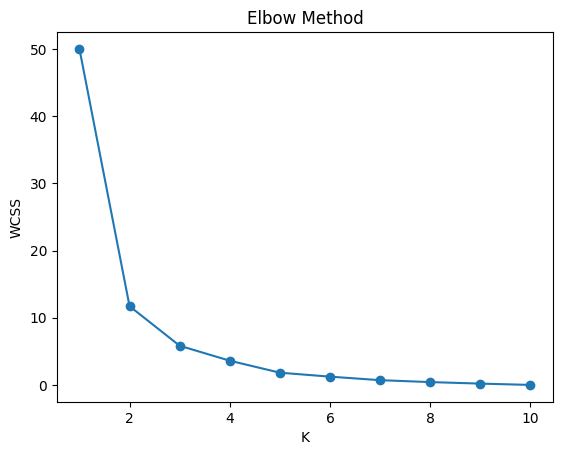

In [68]:
# Step 6: Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [69]:
# Step 7: Silhouette Scores
print("\nSilhouette Scores:")
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Score={score:.3f}")


Silhouette Scores:
K=2, Score=0.607
K=3, Score=0.520
K=4, Score=0.513
K=5, Score=0.419
K=6, Score=0.303
K=7, Score=0.224
K=8, Score=0.174
K=9, Score=0.066


In [70]:
# Step 8: Final model (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
print("\nCluster Labels:")
print(df[["CustomerID", "Cluster"]])


Cluster Labels:
   CustomerID  Cluster
0           1        2
1           2        1
2           3        0
3           4        0
4           5        1
5           6        0
6           7        2
7           8        2
8           9        0
9          10        1


In [71]:
# Step 9: Centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=X.columns)
print("\nCluster Centroids:")
print(centroids_df)


Cluster Centroids:
         Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0  51.000000  68750.000000          12.75        2.000000     157.500000
1  25.333333  22666.666667          76.00        5.666667     450.000000
2  30.000000  32333.333333          48.00        4.333333     273.333333


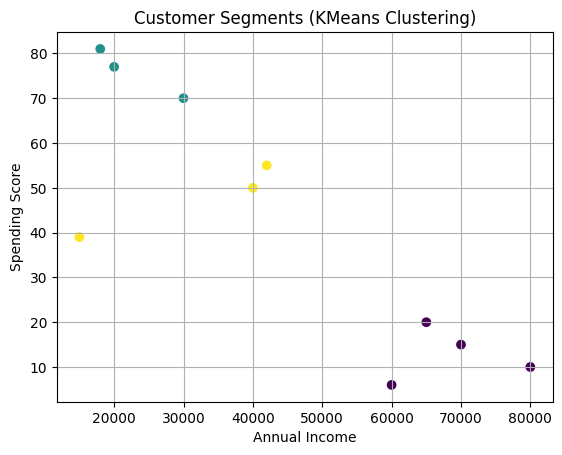

In [72]:
# Step 10: Visualization (2D Clusters)
plt.figure()
plt.scatter(
    df["AnnualIncome"],
    df["SpendingScore"],
    c=df["Cluster"],
    cmap="viridis"
)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments (KMeans Clustering)")
plt.grid(True)
plt.show()